In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


Load dataset and print first 5 rows

In [91]:
df = pd.read_csv("insurance.csv")
#first 5 row
print(df.head())


   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


Shape(rows,Columns) and check basic information

In [92]:
print("Shape",df.shape)
print(df.info())

Shape (1338, 7)
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None


Check Missing Values

In [93]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


Print Statistical Summary

In [94]:
print(df.describe())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


Check for duplicate row

In [95]:
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 1


In [96]:
df = df.drop_duplicates()

In [97]:
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 0


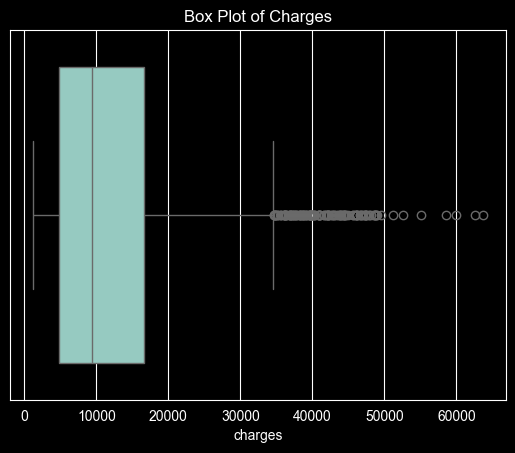

In [98]:
sns.boxplot(x=df["charges"])
plt.title("Box Plot of Charges")
plt.show()

Exploratory Data Analysis : Charges Distribution

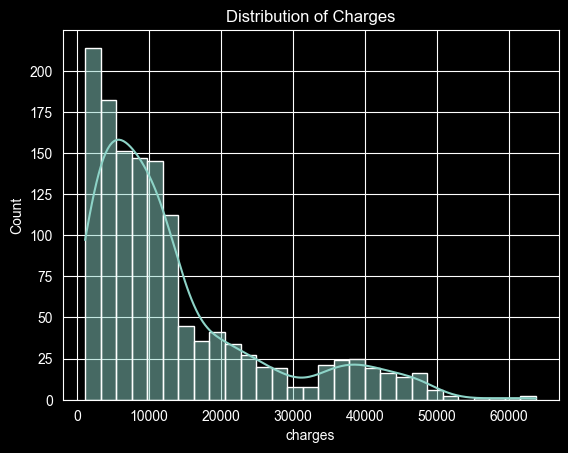

In [99]:
plt.figure()
sns.histplot(df["charges"],kde=True)
plt.title("Distribution of Charges")
plt.show()

Correlation Heatmap

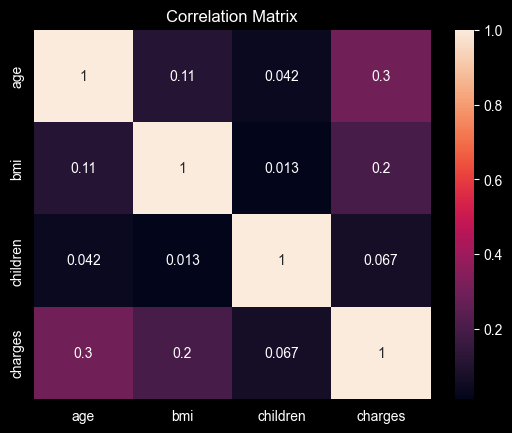

In [100]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.title("Correlation Matrix")
plt.show()


Smoker Vs Charges

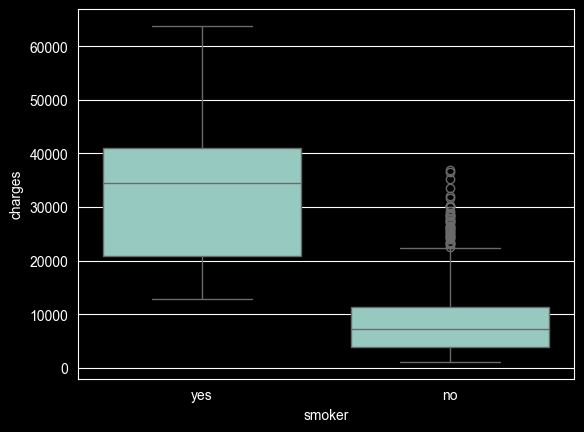

In [101]:
plt.figure()
sns.boxplot(x="smoker", y="charges", data=df)
plt.show()

Features and Taget Separate

In [113]:
X = df.drop("charges",axis=1)
Y = df["charges"]

X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


Define Column Types - Numeric and Categorical

In [109]:
categorical_cols = ["sex", "smoker", "region"]
numerical_cols = ["age", "bmi", "children"]

In [110]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(drop="first"), categorical_cols)
    ]
)

In [114]:
X_processed = preprocessor.fit_transform(X)

In [116]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, Y, test_size=0.2, random_state=42
)

In [117]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [118]:
y_pred = model.predict(X_test)

In [119]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
results.head(10)

,Actual,Predicted
0,8688.85885,8143.693884
1,5708.86700,5737.115683
2,11436.73815,14369.314876
3,38746.35510,31745.513636
4,4463.20510,8962.386657
5,9304.70190,13149.722353
6,38511.62830,30446.760679
7,2150.46900,1453.288813
8,7345.72660,10633.018402
9,10264.44210,11318.943794


In [121]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("R2 Score:", r2)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)


R2 Score: 0.8069287081198011
MSE: 35478020.675235614
RMSE: 5956.342894363589
MAE: 4177.045561036324


Text(0, 0.5, 'Predicted Charges')

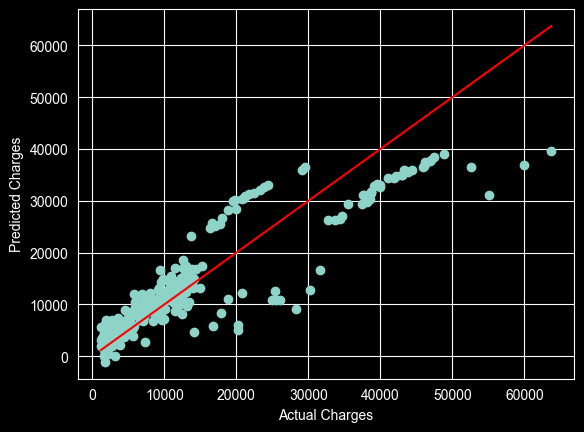

In [122]:
plt.figure()
plt.scatter(y_test,y_pred)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],color="red")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")